In [ ]:
# Install and load necessary packages
install.packages(c("tidyverse", "ggplot2", "plotly", "lubridate"))
library(tidyverse)
library(ggplot2)
library(plotly)
library(lubridate)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘lazyeval’, ‘crosstalk’


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘plotly’


The following object is masked from ‘package:ggplot2’:

    last_plot


The following object is masked from ‘package:stats’:

    filter


The following object is masked from ‘package:graphics’:

    layout




In [ ]:
# Load the dataset
car_data <- read.csv("/content/Car_sales.csv")

head(car_data)

,Manufacturer,Model,Sales_in_thousands,X__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<dbl>
1,Acura,Integra,16.919,16.360,Passenger,21.50,1.8,140,101.2,67.3,172.4,2.639,13.2,28,2/2/2012,58.28015
2,Acura,TL,39.384,19.875,Passenger,28.40,3.2,225,108.1,70.3,192.9,3.517,17.2,25,6/3/2011,91.37078
3,Acura,CL,14.114,18.225,Passenger,NA,3.2,225,106.9,70.6,192.0,3.470,17.2,26,1/4/2012,NA
4,Acura,RL,8.588,29.725,Passenger,42.00,3.5,210,114.6,71.4,196.6,3.850,18.0,22,3/10/2011,91.38978
5,Audi,A4,20.397,22.255,Passenger,23.99,1.8,150,102.6,68.2,178.0,2.998,16.4,27,10/8/2011,62.77764
6,Audi,A6,18.780,23.555,Passenger,33.95,2.8,200,108.7,76.1,192.0,3.561,18.5,22,8/9/2011,84.56511


In [ ]:
# Check the structure of the dataset
str(car_data)

'data.frame':	157 obs. of  16 variables:
 $ Manufacturer        : chr  "Acura" "Acura" "Acura" "Acura" ...
 $ Model               : chr  "Integra" "TL" "CL" "RL" ...
 $ Sales_in_thousands  : num  16.92 39.38 14.11 8.59 20.4 ...
 $ X__year_resale_value: num  16.4 19.9 18.2 29.7 22.3 ...
 $ Vehicle_type        : chr  "Passenger" "Passenger" "Passenger" "Passenger" ...
 $ Price_in_thousands  : num  21.5 28.4 NA 42 24 ...
 $ Engine_size         : num  1.8 3.2 3.2 3.5 1.8 2.8 4.2 2.5 2.8 2.8 ...
 $ Horsepower          : int  140 225 225 210 150 200 310 170 193 193 ...
 $ Wheelbase           : num  101 108 107 115 103 ...
 $ Width               : num  67.3 70.3 70.6 71.4 68.2 76.1 74 68.4 68.5 70.9 ...
 $ Length              : num  172 193 192 197 178 ...
 $ Curb_weight         : num  2.64 3.52 3.47 3.85 3 ...
 $ Fuel_capacity       : num  13.2 17.2 17.2 18 16.4 18.5 23.7 16.6 16.6 18.5 ...
 $ Fuel_efficiency     : int  28 25 26 22 27 22 21 26 24 25 ...
 $ Latest_Launch       : chr  "2/2/201

In [ ]:
# Display summary statistics
summary(car_data)

 Manufacturer          Model           Sales_in_thousands X__year_resale_value
 Length:157         Length:157         Min.   :  0.11     Min.   : 5.16       
 Class :character   Class :character   1st Qu.: 14.11     1st Qu.:11.26       
 Mode  :character   Mode  :character   Median : 29.45     Median :14.18       
                                       Mean   : 53.00     Mean   :18.07       
                                       3rd Qu.: 67.96     3rd Qu.:19.88       
                                       Max.   :540.56     Max.   :67.55       
                                                          NA's   :36          
 Vehicle_type       Price_in_thousands  Engine_size      Horsepower   
 Length:157         Min.   : 9.235     Min.   :1.000   Min.   : 55.0  
 Class :character   1st Qu.:18.017     1st Qu.:2.300   1st Qu.:149.5  
 Mode  :character   Median :22.799     Median :3.000   Median :177.5  
                    Mean   :27.391     Mean   :3.061   Mean   :185.9  
             

In [ ]:
# Check for null values
colSums(is.na(car_data))

# Check for duplicate records
duplicate_rows <- car_data[duplicated(car_data), ]

# Display the duplicate rows
print(duplicate_rows)

Manufacturer                Model   Sales_in_thousands 
                   0                    0                    0 
X__year_resale_value         Vehicle_type   Price_in_thousands 
                  36                    0                    2 
         Engine_size           Horsepower            Wheelbase 
                   1                    1                    1 
               Width               Length          Curb_weight 
                   1                    1                    2 
       Fuel_capacity      Fuel_efficiency        Latest_Launch 
                   1                    3                    0 
   Power_perf_factor 
                   2

 [1] Manufacturer         Model                Sales_in_thousands  
 [4] X__year_resale_value Vehicle_type         Price_in_thousands  
 [7] Engine_size          Horsepower           Wheelbase           
[10] Width                Length               Curb_weight         
[13] Fuel_capacity        Fuel_efficiency      Latest_Launch       
[16] Power_perf_factor   
<0 rows> (or 0-length row.names)


Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


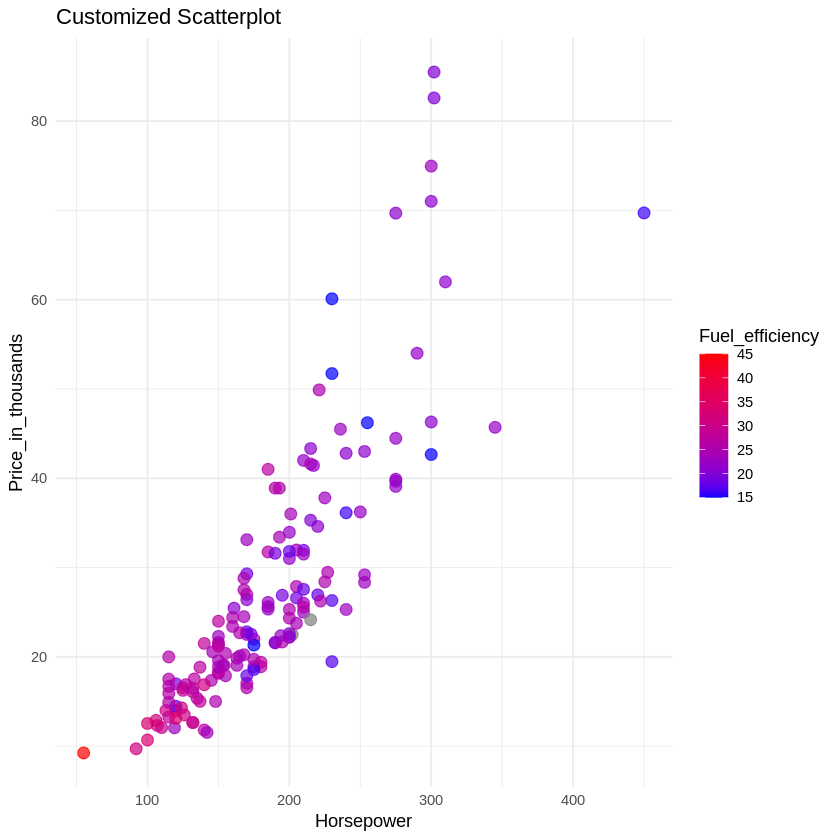

In [ ]:
# Install and load necessary packages
# install.packages("ggplot2")
library(ggplot2)

# Customize Scatterplot
custom_scatterplot <- ggplot(car_data, aes(x = Horsepower, y = Price_in_thousands,
                                           color = Fuel_efficiency)) +
  geom_point(size = 3, alpha = 0.7) +
  scale_color_gradient(low = "blue", high = "red") +  # Adjust color scale
  labs(
    title = "Customized Scatterplot",
    x = "Horsepower",
    y = "Price_in_thousands",
    color = "Fuel_efficiency"
  ) +
  theme_minimal()

# Show the scatterplot
print(custom_scatterplot)

Warning message:
“The dot-dot notation (`..density..`) was deprecated in ggplot2 3.4.0.
ℹ Please use `after_stat(density)` instead.”
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_density()`).”


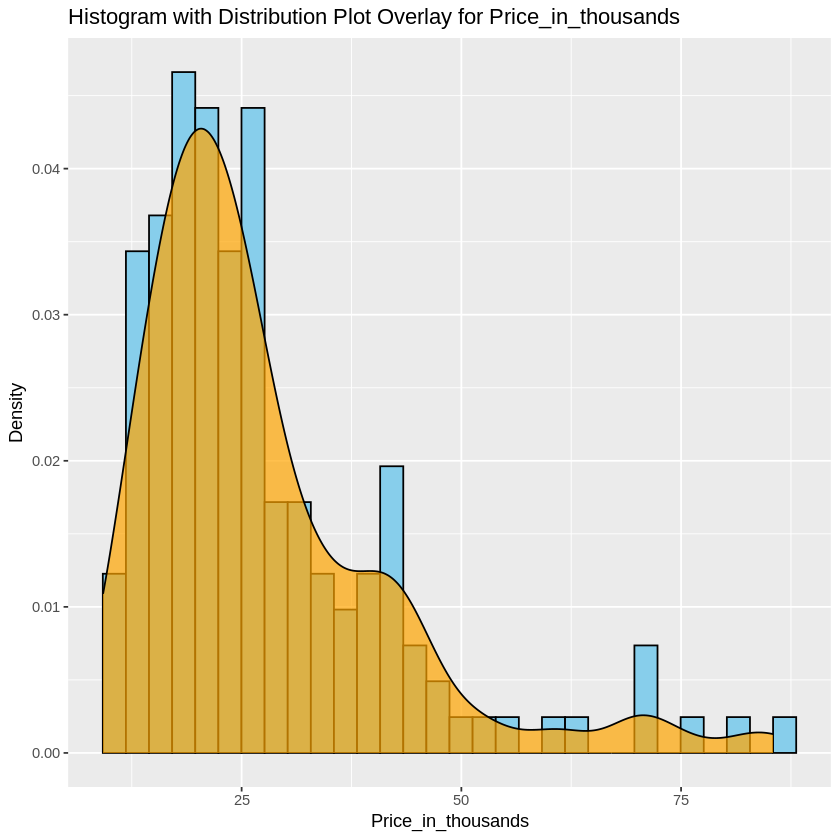

In [ ]:
# Assuming 'Price_in_thousands' is the column of interest in your 'car_data' dataframe
ggplot(car_data, aes(x = Price_in_thousands)) +
  geom_histogram(aes(y = ..density..), fill = "skyblue", color = "black", bins = 30) +
  geom_density(alpha = 0.7, fill = "orange") +
  labs(title = "Histogram with Distribution Plot Overlay for Price_in_thousands",
       x = "Price_in_thousands",
       y = "Density")

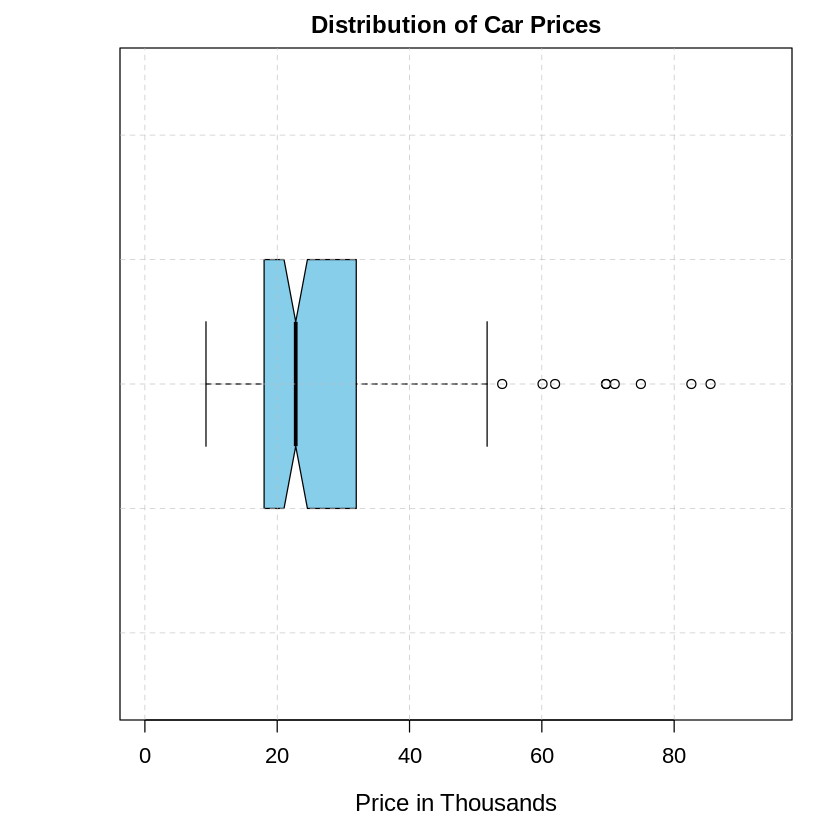

In [ ]:
# Set up a larger plotting area
par(mar = c(5, 5, 2, 2))

# Create a boxplot with enhanced features
boxplot(car_data$Price_in_thousands,
        main = "Distribution of Car Prices",
        col = "skyblue",
        border = "black",
        horizontal = TRUE,  # Display as a horizontal boxplot
        notch = TRUE,       # Add a notch for median confidence interval
        notchwidth = 0.5,   # Adjust the width of the notch
        outline = TRUE,     # Show individual data points
        cex.main = 1.2,     # Increase the title font size
        cex.axis = 1.1,     # Increase the axis label font size
        cex.lab = 1.1,      # Increase the axis tick label font size
        ylim = c(0, max(car_data$Price_in_thousands, na.rm = TRUE) * 1.1)
)

# Add labels and grid
title(xlab = "Price in Thousands", cex.lab = 1.2)
title(ylab = "")
grid(lty = 2, col = "gray", lwd = 0.5)

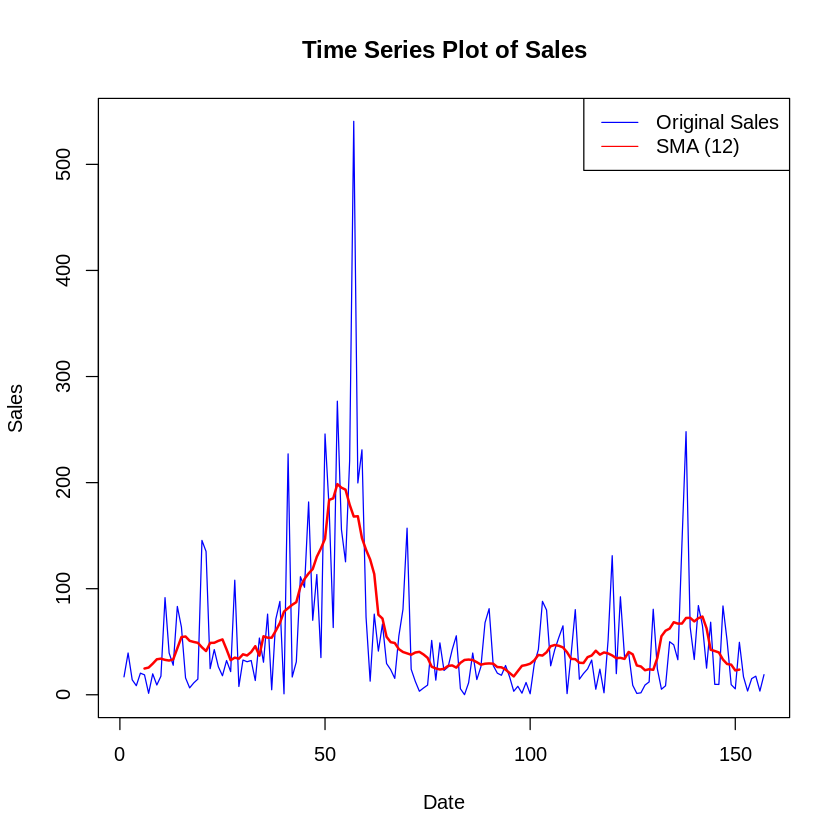

In [ ]:
# Create a time series object
ts_data <- ts(car_data$Sales_in_thousands , frequency = 1)

# Time Series Plot
plot(ts_data, main = "Time Series Plot of Sales", xlab = "Date", ylab = "Sales",
     col = "blue", type = "l")

# Apply a Simple Moving Average (SMA) to smooth the series
sma_window <- 12  # Set the window size for the moving average
sma <- stats::filter(ts_data, rep(1/sma_window, sma_window), sides = 2)

# Overlay the moving average on the plot
lines(sma, col = "red", lwd = 2)

# Add legend
legend("topright", legend = c("Original Sales", paste("SMA (", sma_window, ")",
                                         sep = "")), col = c("blue", "red"), lty = 1)

In [ ]:
install.packages("randomForest")
library(randomForest)

# Split the dataset into training and testing sets
set.seed(123)
car <- car_data[c("Engine_size","Horsepower","Price_in_thousands","Fuel_efficiency","Sales_in_thousands")]

car <- drop_na(car)

# Splitting the data into training and testing sets
train_indices <- sample(1:nrow(car), 0.8 * nrow(car))  # Use 'car' here instead of 'car_data'
train_data <- car[train_indices, ]
test_data <- car[-train_indices, ]

mtry_opt <- floor(sqrt(ncol(train_data) - 1))

# Train a Random Forest regression model with hyperparameter tuning
rf_model <- randomForest(
  Sales_in_thousands ~ .,
  data      = train_data,
  ntree     = 500,          # more trees → stabler model
  mtry      = mtry_opt,     # Ensure mtry_opt is defined or set a value
  nodesize  = 5,
  importance = TRUE
)

# Make predictions
pred <- predict(rf_model, newdata = test_data)

# Calculate RMSE
rmse <- sqrt(mean((pred - test_data$Sales_in_thousands)^2))
cat("Root‑Mean‑Squared‑Error (RMSE):", round(rmse, 4), "\n")

# Calculate Mapping Accuracy
mapping_accuracy <- 1 - (rmse / sd(test_data$Sales_in_thousands))
cat("Mapping Accuracy:", round(mapping_accuracy, 4), "\n")


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Root‑Mean‑Squared‑Error (RMSE): 99.3076 
Mapping Accuracy: 0.0542 


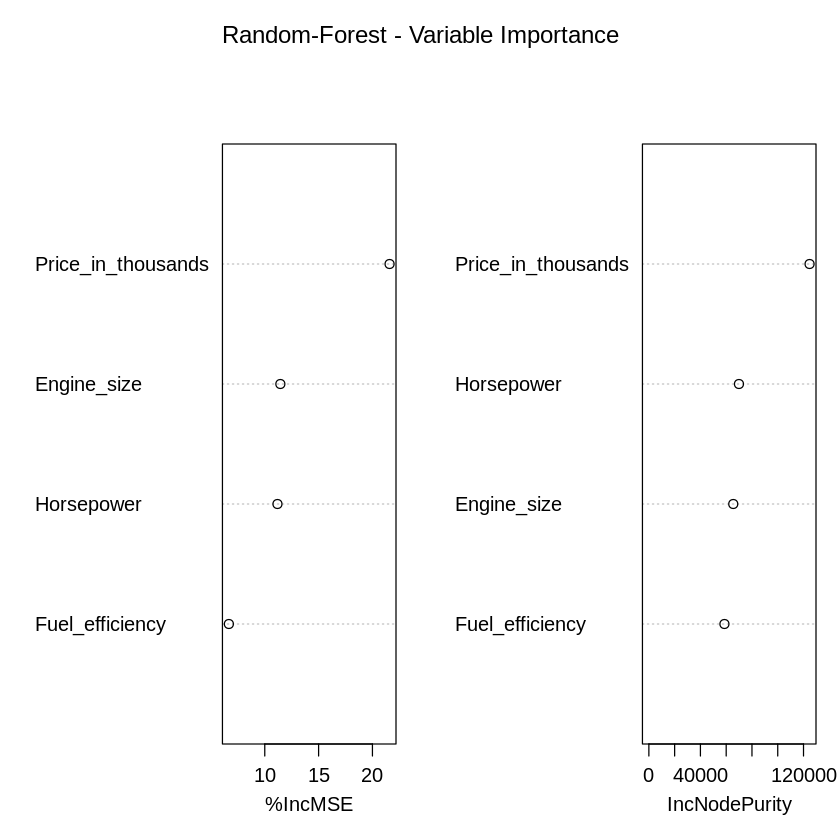

In [ ]:
varImpPlot(rf_model, main = "Random‑Forest ‑ Variable Importance")

In [ ]:
new_observation <- data.frame(
  Price_in_thousands = c(25),
  Engine_size = c(2),
  Horsepower = c(150),
  Fuel_efficiency = c(25)
)

future_prediction <- predict(rf_model, newdata = new_observation)

print(future_prediction)


       1 
22.58741 
